# Exploratory Data Analysis — `factory_cleaned.csv`

**Dataset**: Processed Singapore factory/industrial property transactions (Jan 2023 – Dec 2025)  
**Target**: `Unit Price ($ psf)`  
**Rows**: 3,789 | **Columns**: 33

---

## Contents
1. Imports & Data Loading
2. Dataset Overview
3. Missing Values & Duplicates
4. Target Variable Analysis
5. Numerical Features Summary
6. Categorical Features Analysis
7. Temporal Analysis
8. Numerical Feature Correlations with Target
9. Categorical Features vs Target
10. Data Quality Flags
11. Macro Features Assessment
12. EDA Summary & Recommendations

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/processed/factory_cleaned.csv")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

macro_cols = [
    "GDP_YoY_Growth_Rate", "CPI_All_Items", "Unemployment_Rate", "Price_Index",
    "5Y_Bond_Yield", "2Y_Bond_Yield", "10Y_Bond_Yield", "1Y_TBills",
    "15Y_Bond_Yield", "20Y_Bond_Yield", "SORA_3M_Compounded",
    "Cement_Bulk_Per_Tonne", "Steel_Rebar_Per_Tonne",
    "Granite_20mm_Per_Tonne", "Concreting_Sand_Per_Tonne", "Ready_Mixed_Concrete_Per_m3",
]


Shape: 3789 rows x 32 columns


## 2. Dataset Overview

In [2]:
# Column names, types, and non-null counts
print(f"{'Column':<30} {'Dtype':<12} {'Non-Null':>10}")
print("-" * 55)
for col in df.columns:
    print(f"{col:<30} {str(df[col].dtype):<12} {df[col].notna().sum():>10}")

Column                         Dtype          Non-Null
-------------------------------------------------------
Contract Date                  object             3789
Project Name                   object             3763
Street Name                    object             3789
Area (sqft)                    float64            3789
Floor Level                    object             3789
Unit Price ($ psf)             float64            3789
Type of Sale                   object             3789
Region                         object             3789
Planning Area                  object             3789
Postal District                float64            3789
Postal Sector                  float64            3789
Year                           int64              3789
Month                          int64              3789
Quarter                        int64              3789
Lease_Duration                 float64            3789
Remaining_Lease_Years          float64            3789
GDP_YoY_G

## 3. Missing Values & Duplicates

In [3]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Count": missing, "Pct (%)": missing_pct})
missing_df = missing_df[missing_df["Count"] > 0]

if missing_df.empty:
    print("No missing values found.")
else:
    print("Columns with missing values:")
    display(missing_df)

# Duplicates
dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes} ({dupes/len(df)*100:.2f}%)")

Columns with missing values:


,Count,Pct (%)
Project Name,26,0.69



Duplicate rows: 0 (0.00%)


## 4. Target Variable Analysis - `Unit Price ($ psf)`

=== Target Variable Summary ===
  Mean        : 441.28
  Median      : 434.00
  Std Dev     : 179.08
  Min         : 30.00
  Max         : 1460.00
  Skewness    : 0.83
  Kurtosis    : 1.99

Percentiles:
  P1  : $109.88
  P5  : $191.00
  P25 : $302.00
  P50 : $434.00
  P75 : $558.00
  P95 : $703.20
  P99 : $1044.00


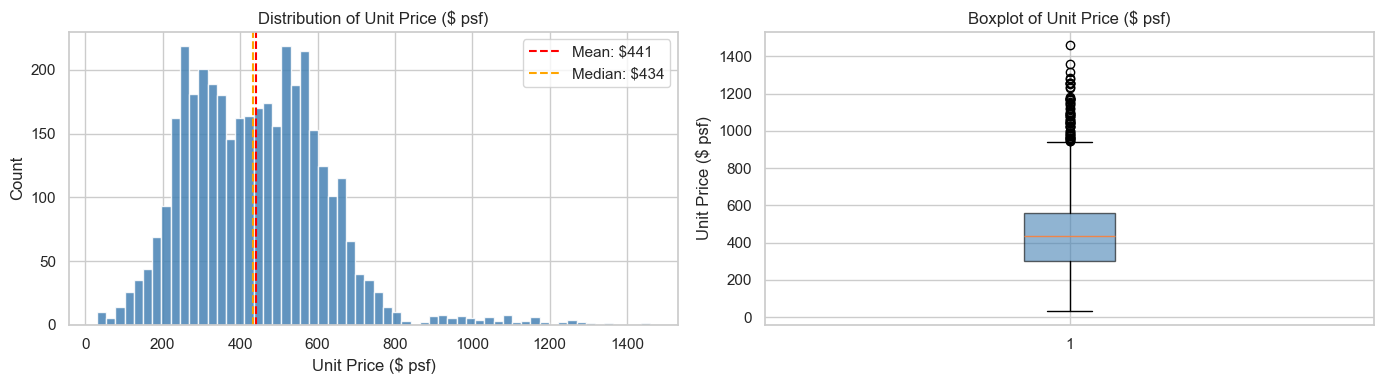

In [4]:
target = df["Unit Price ($ psf)"]

# Summary stats
stats = {
    "Mean": target.mean(), "Median": target.median(), "Std Dev": target.std(),
    "Min": target.min(), "Max": target.max(),
    "Skewness": target.skew(), "Kurtosis": target.kurtosis()
}
print("=== Target Variable Summary ===")
for k, v in stats.items():
    print(f"  {k:<12}: {v:.2f}")

print("\nPercentiles:")
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"  P{p:<3}: ${target.quantile(p/100):.2f}")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(target, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(target.mean(), color="red", linestyle="--", label=f"Mean: ${target.mean():.0f}")
axes[0].axvline(target.median(), color="orange", linestyle="--", label=f"Median: ${target.median():.0f}")
axes[0].set_title("Distribution of Unit Price ($ psf)")
axes[0].set_xlabel("Unit Price ($ psf)")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].boxplot(target, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_title("Boxplot of Unit Price ($ psf)")
axes[1].set_ylabel("Unit Price ($ psf)")

plt.tight_layout()
plt.show()

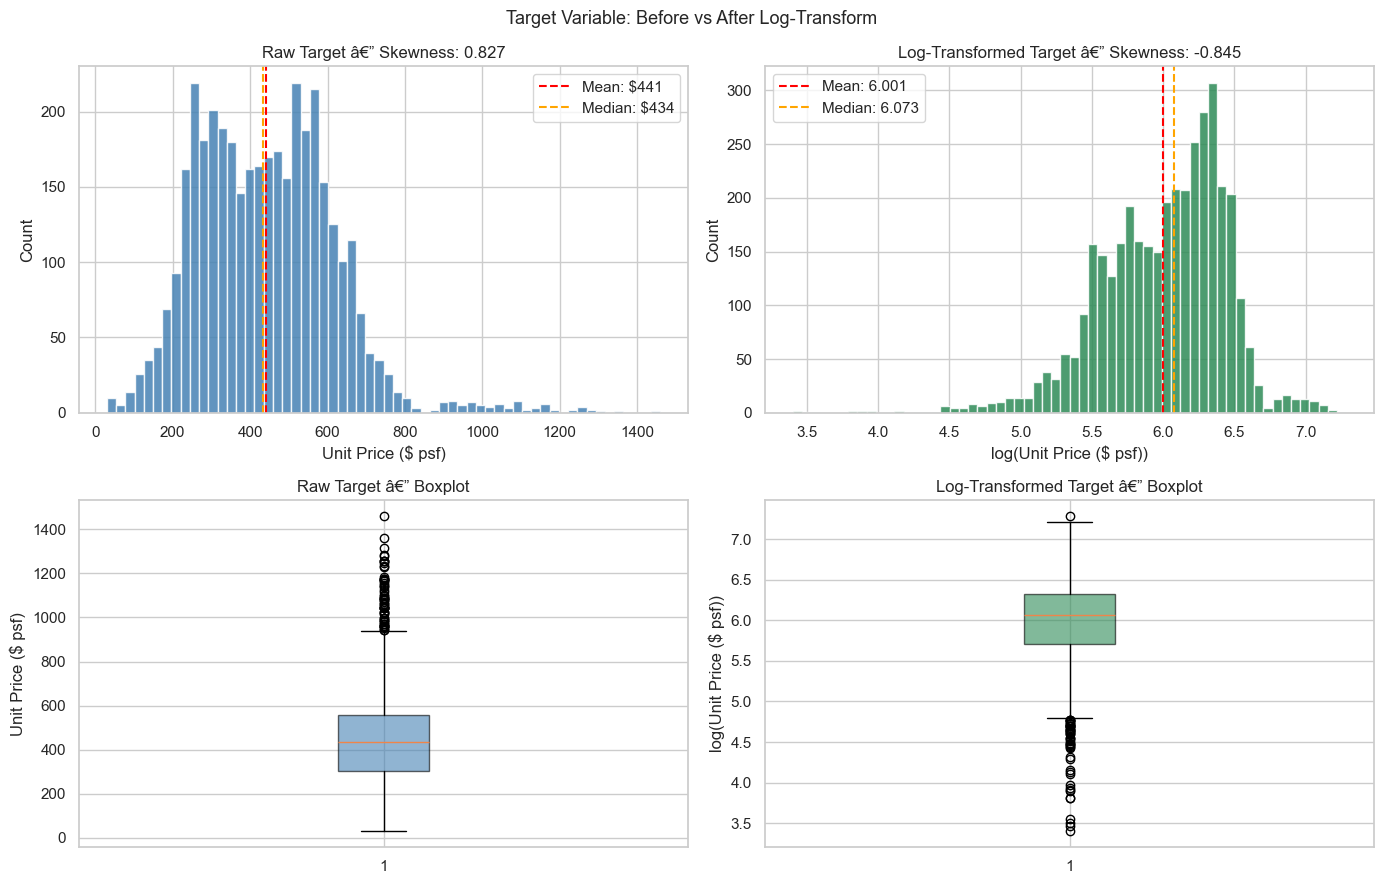

Raw target     â€” Skewness: 0.827  | Kurtosis: 1.994
Log target     â€” Skewness: -0.845  | Kurtosis: 2.028

Raw target     â€” Mean: $441.28  | Std: $179.08
Log target     â€” Mean: 6.0006  | Std: 0.4447


In [5]:
# Before vs After Log-Transform of Target
log_target = np.log(target)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# --- Raw distribution ---
axes[0, 0].hist(target, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[0, 0].axvline(target.mean(), color="red", linestyle="--", label=f"Mean: ${target.mean():.0f}")
axes[0, 0].axvline(target.median(), color="orange", linestyle="--", label=f"Median: ${target.median():.0f}")
axes[0, 0].set_title(f"Raw Target â€” Skewness: {target.skew():.3f}")
axes[0, 0].set_xlabel("Unit Price ($ psf)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

# --- Log-transformed distribution ---
axes[0, 1].hist(log_target, bins=60, color="seagreen", edgecolor="white", alpha=0.85)
axes[0, 1].axvline(log_target.mean(), color="red", linestyle="--", label=f"Mean: {log_target.mean():.3f}")
axes[0, 1].axvline(log_target.median(), color="orange", linestyle="--", label=f"Median: {log_target.median():.3f}")
axes[0, 1].set_title(f"Log-Transformed Target â€” Skewness: {log_target.skew():.3f}")
axes[0, 1].set_xlabel("log(Unit Price ($ psf))")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()

# --- Raw boxplot ---
axes[1, 0].boxplot(target, vert=True, patch_artist=True,
                   boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1, 0].set_title("Raw Target â€” Boxplot")
axes[1, 0].set_ylabel("Unit Price ($ psf)")

# --- Log-transformed boxplot ---
axes[1, 1].boxplot(log_target, vert=True, patch_artist=True,
                   boxprops=dict(facecolor="seagreen", alpha=0.6))
axes[1, 1].set_title("Log-Transformed Target â€” Boxplot")
axes[1, 1].set_ylabel("log(Unit Price ($ psf))")

plt.suptitle("Target Variable: Before vs After Log-Transform", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Raw target     â€” Skewness: {target.skew():.3f}  | Kurtosis: {target.kurtosis():.3f}")
print(f"Log target     â€” Skewness: {log_target.skew():.3f}  | Kurtosis: {log_target.kurtosis():.3f}")
print(f"\nRaw target     â€” Mean: ${target.mean():.2f}  | Std: ${target.std():.2f}")
print(f"Log target     â€” Mean: {log_target.mean():.4f}  | Std: {log_target.std():.4f}")

## 5. Numerical Features Summary

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].describe().round(2)

,Area (sqft),Unit Price ($ psf),Postal District,Postal Sector,Year,Month,Quarter,Lease_Duration,Remaining_Lease_Years,GDP_YoY_Growth_Rate,...,10Y_Bond_Yield,1Y_TBills,15Y_Bond_Yield,20Y_Bond_Yield,SORA_3M_Compounded,Cement_Bulk_Per_Tonne,Steel_Rebar_Per_Tonne,Granite_20mm_Per_Tonne,Concreting_Sand_Per_Tonne,Ready_Mixed_Concrete_Per_m3
count,3789.00,3789.00,3789.00,3789.00,3789.00,3789.00,3789.00,3789.00,3789.00,3789.00,...,3789.00,3789.00,3789.00,3789.00,3789.00,3789.00,3789.00,3789.00,3789.00,3789.00
mean,2513.07,441.28,19.93,56.63,2024.00,6.53,2.52,52.00,32.84,3.97,...,2.78,2.97,2.78,2.74,3.04,109.68,788.26,21.18,27.93,119.19
std,2666.38,179.08,5.85,15.95,0.81,3.31,1.09,16.71,11.68,6.74,...,0.44,0.85,0.41,0.39,0.84,5.24,84.35,1.66,0.94,2.46
min,517.00,30.00,3.00,12.00,2023.00,1.00,1.00,19.00,1.90,-8.60,...,1.83,1.35,1.93,1.92,1.19,101.10,660.30,18.30,26.40,115.40
25%,1378.00,302.00,14.00,41.00,2023.00,4.00,2.00,30.00,20.20,0.70,...,2.62,2.55,2.60,2.57,2.55,104.20,701.30,19.50,27.30,117.30
50%,1765.00,434.00,22.00,62.00,2024.00,7.00,3.00,60.00,33.40,4.40,...,2.86,3.46,2.83,2.81,3.57,110.00,805.70,22.10,27.90,119.80
75%,2605.00,558.00,25.00,73.00,2025.00,9.00,3.00,60.00,43.80,10.20,...,3.10,3.62,3.09,3.05,3.65,113.50,830.10,22.30,29.00,120.40
max,73151.00,1460.00,27.00,76.00,2025.00,12.00,4.00,99.00,59.90,14.90,...,3.45,3.93,3.45,3.44,3.75,118.50,946.60,23.00,29.60,129.50


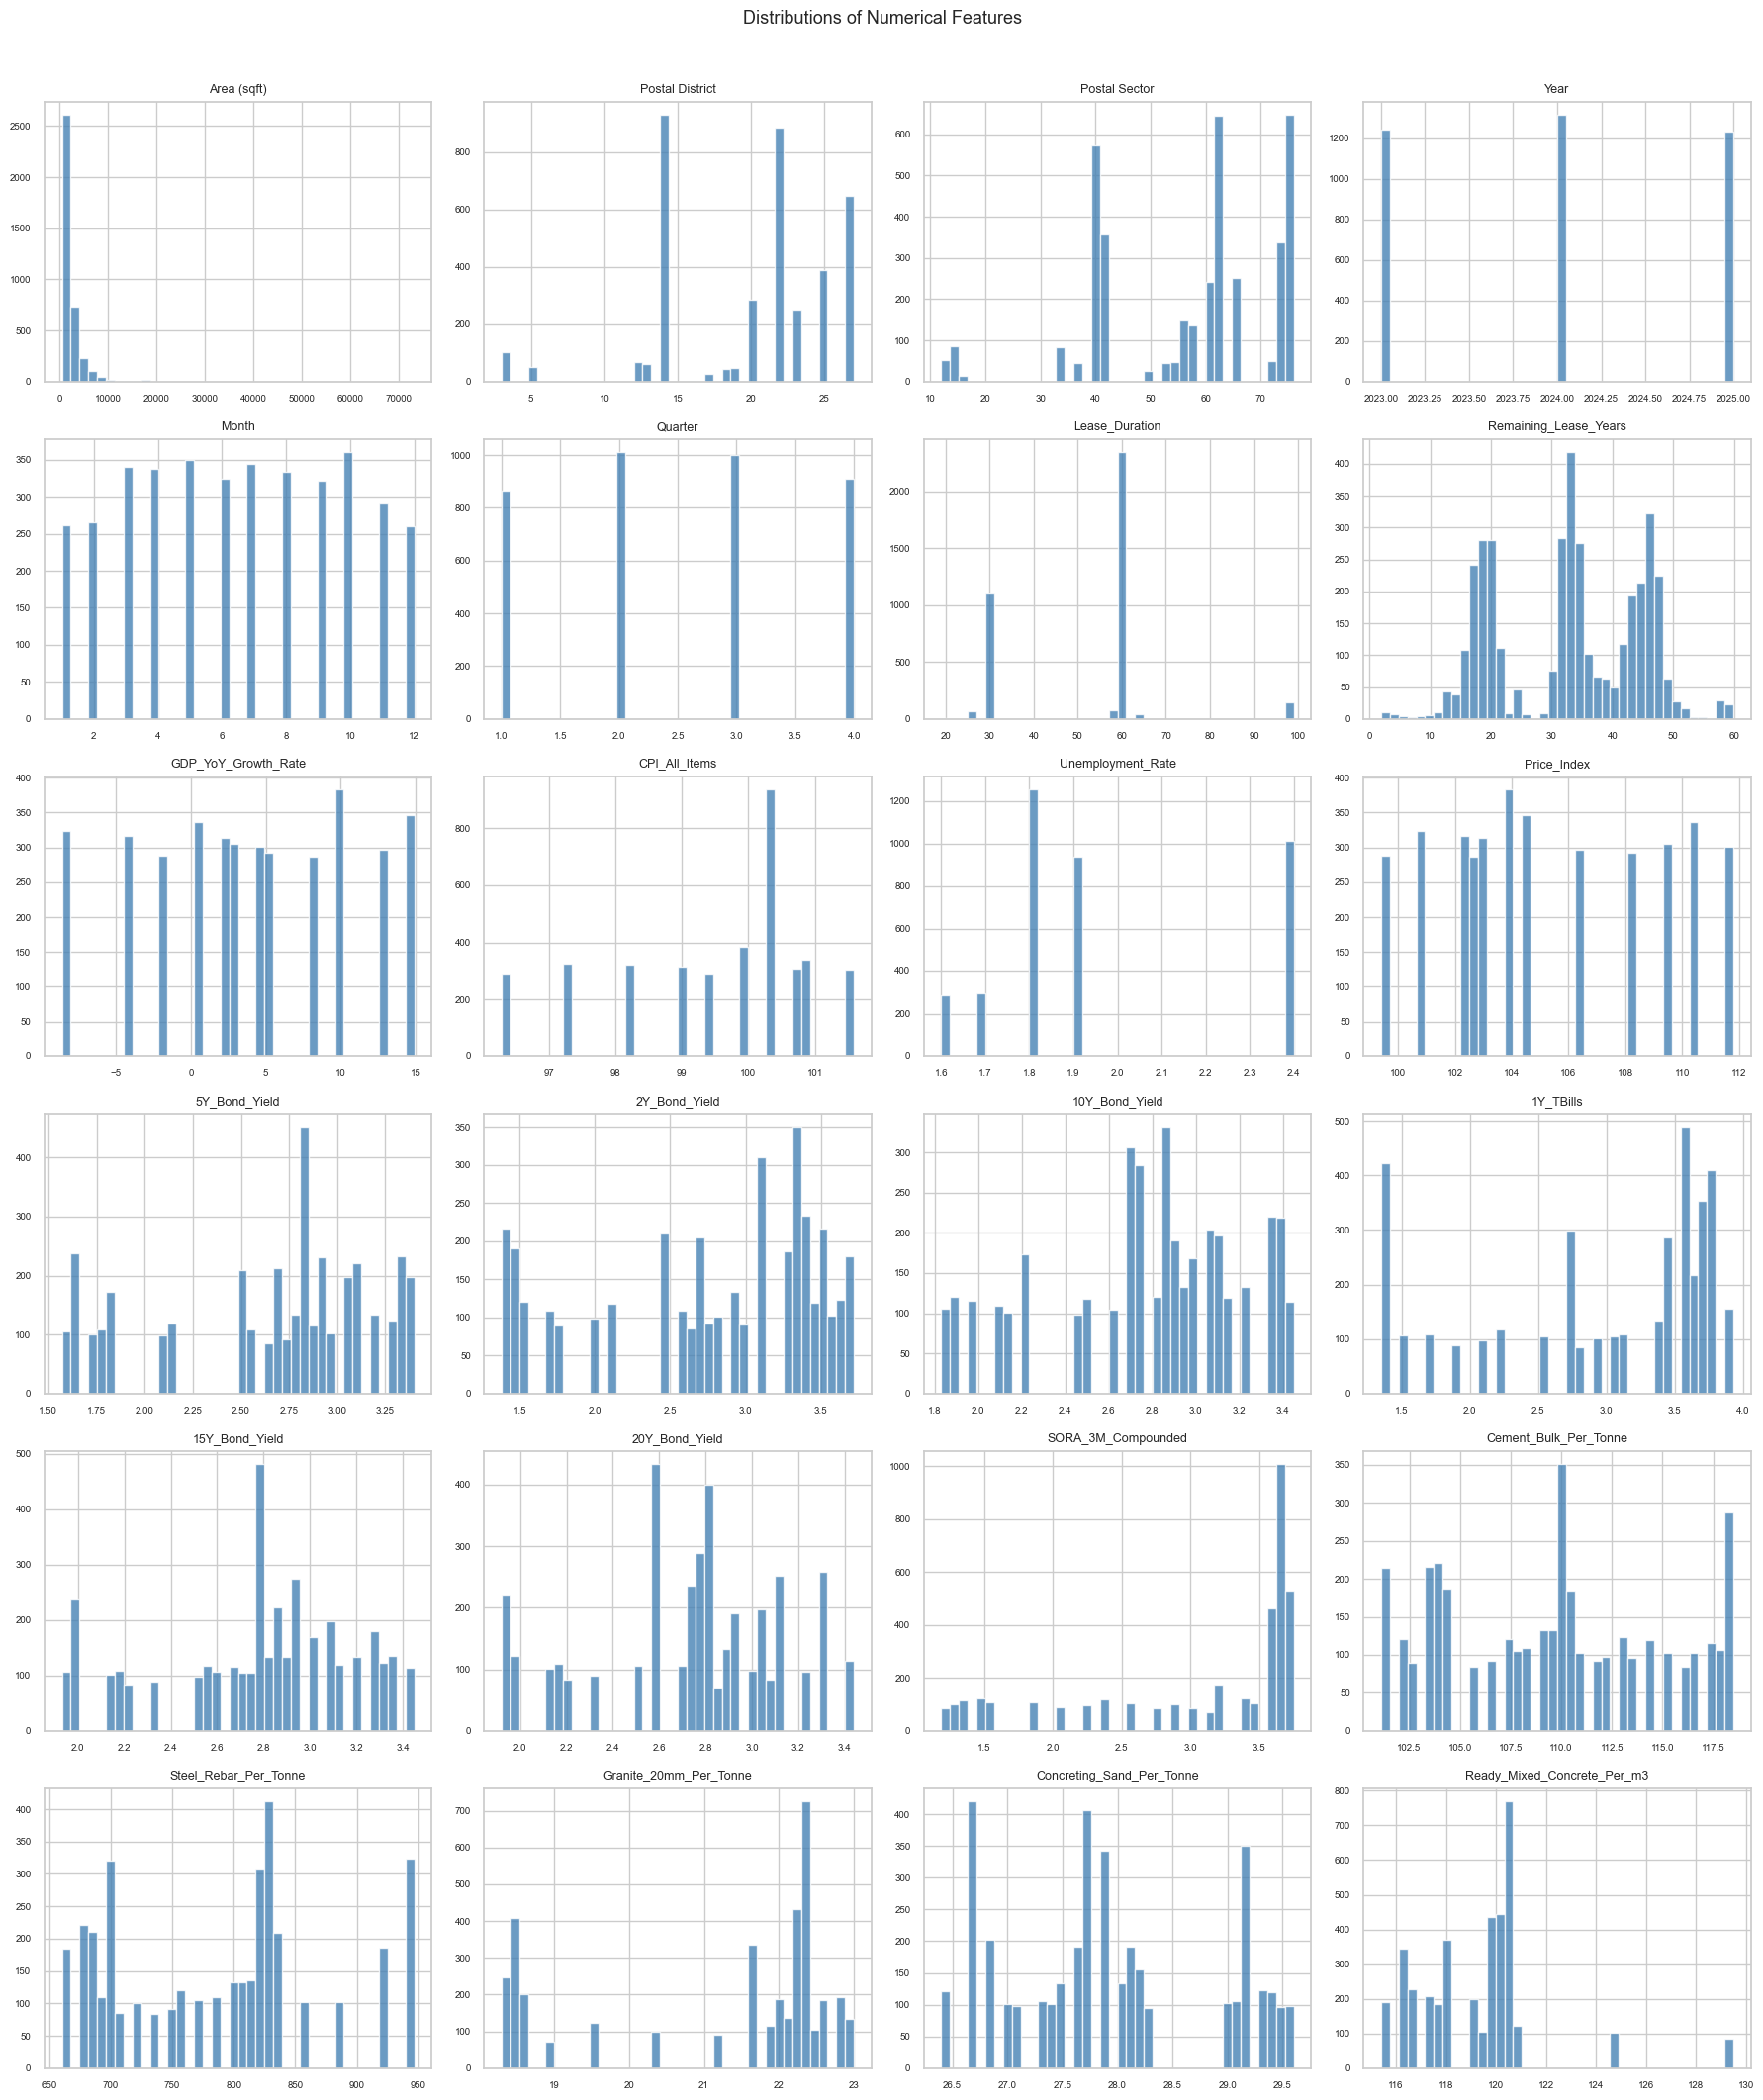

In [7]:
# Distribution plots for all numerical features (excluding target)
feature_cols = [c for c in num_cols if c != "Unit Price ($ psf)"]

n_cols = 4
n_rows = -(-len(feature_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].tick_params(labelsize=7)

# Hide unused subplots
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions of Numerical Features", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Categorical Features Analysis

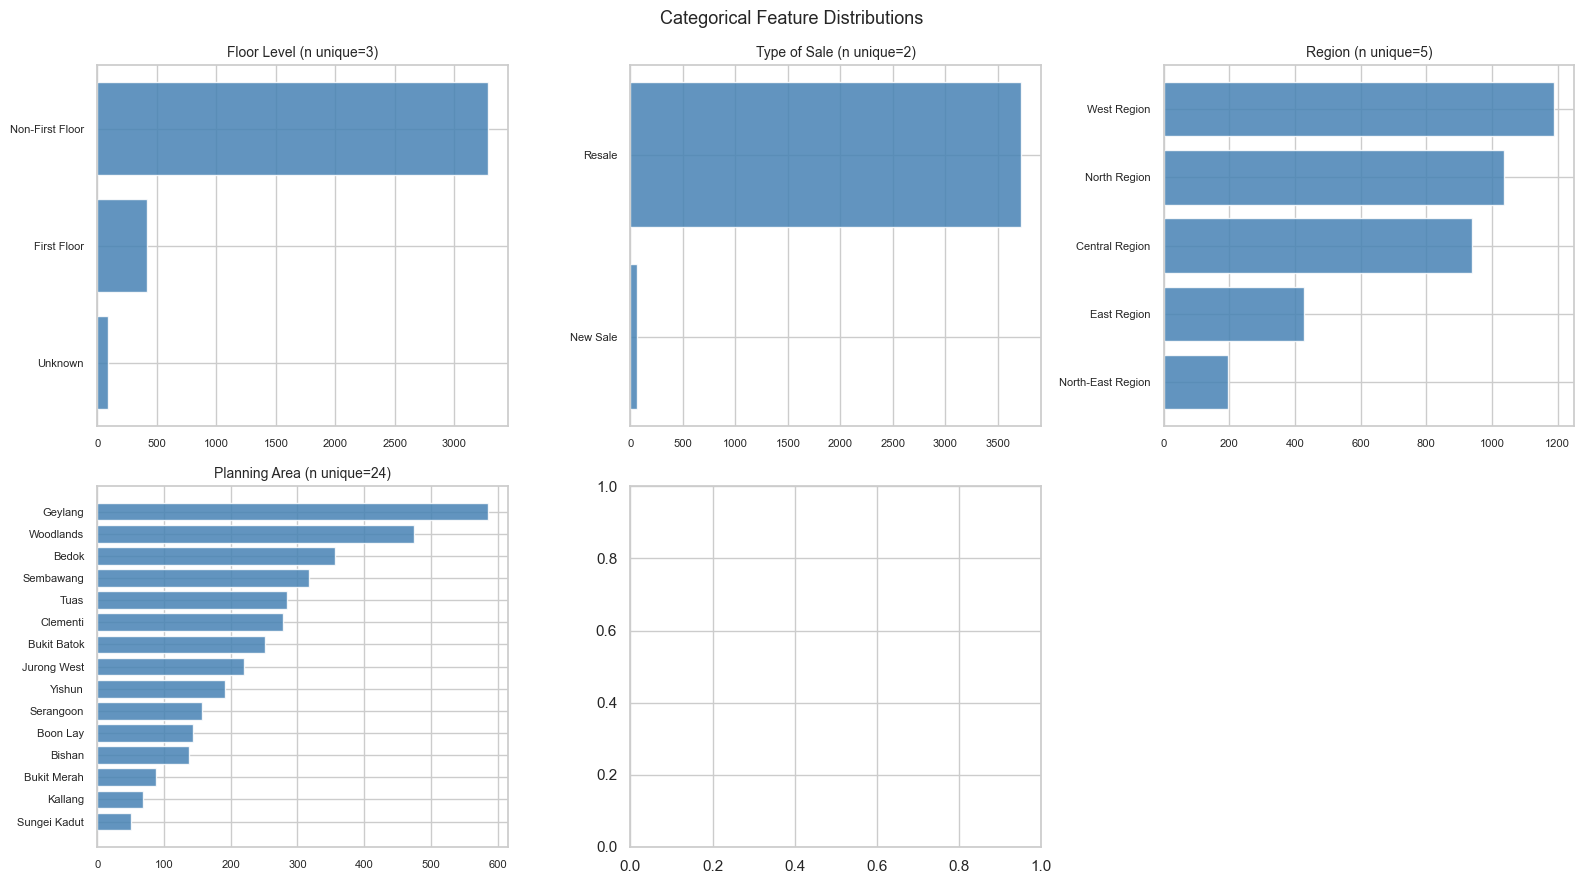


--- Floor Level ---
Floor Level
Non-First Floor    3284
First Floor         415
Unknown              90

--- Type of Sale ---
Type of Sale
Resale      3723
New Sale      66

--- Region ---
Region
West Region          1190
North Region         1035
Central Region        940
East Region           429
North-East Region     195

--- Planning Area ---
Planning Area
Geylang         586
Woodlands       475
Bedok           357
Sembawang       318
Tuas            285
Clementi        279
Bukit Batok     252
Jurong West     220
Yishun          191
Serangoon       157
Boon Lay        143
Bishan          137
Bukit Merah      88
Kallang          69
Sungei Kadut     51
Toa Payoh        46
Tampines         45
Ang Mo Kio       38
Pasir Ris        20
Queenstown       14
Pioneer           7
Changi            6
Jurong East       4
Paya Lebar        1


In [8]:
cat_cols = ["Floor Level", "Type of Sale", "Region", "Planning Area"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].barh(vc.index[:15], vc.values[:15], color="steelblue", alpha=0.85)
    axes[i].set_title(f"{col} (n unique={df[col].nunique()})", fontsize=10)
    axes[i].tick_params(labelsize=8)
    axes[i].invert_yaxis()

axes[-1].set_visible(False)
plt.suptitle("Categorical Feature Distributions", fontsize=13)
plt.tight_layout()
plt.show()

# Print value counts
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().to_string())

## 7. Temporal Analysis

Date range: 2023-01-03 to 2025-12-30

Year distribution:
Year
2023    1241
2024    1314
2025    1234


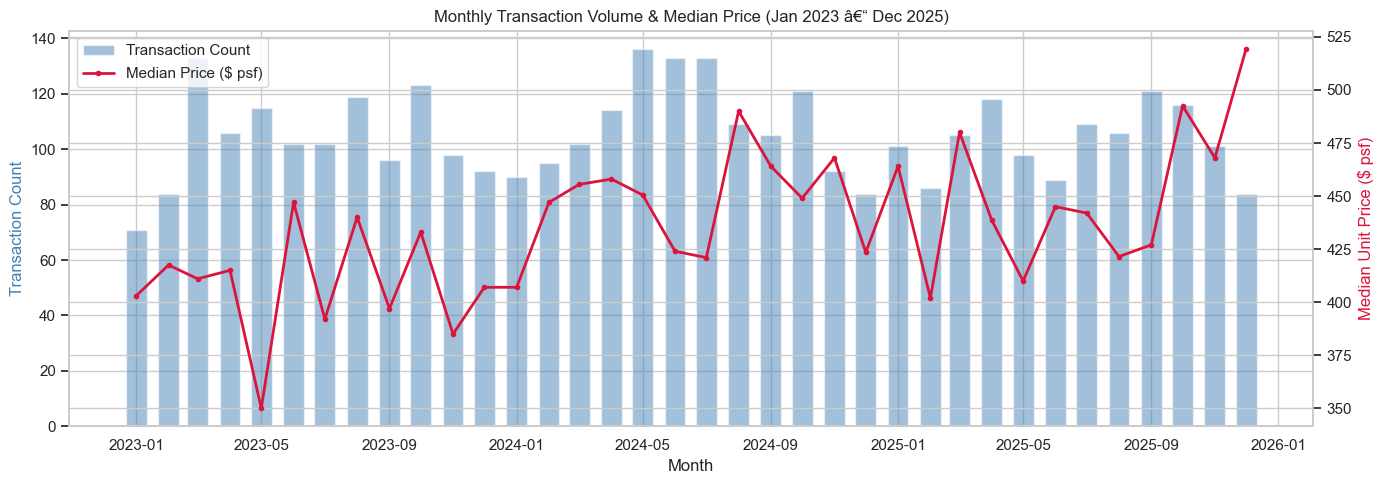


Lease Duration distribution:
Lease_Duration
19.0       5
20.0       2
26.0      64
30.0    1105
41.0       7
45.0       2
57.0      54
58.0      24
60.0    2345
63.0      39
99.0     142


In [9]:
print(f"Date range: {df['Contract Date'].min()} to {df['Contract Date'].max()}")
print(f"\nYear distribution:")
print(df["Year"].value_counts().sort_index().to_string())

# Monthly transaction volume and median price over time
df["Contract Date"] = pd.to_datetime(df["Contract Date"])
monthly = df.groupby(df["Contract Date"].dt.to_period("M")).agg(
    transactions=("Unit Price ($ psf)", "count"),
    median_price=("Unit Price ($ psf)", "median")
).reset_index()
monthly["Contract Date"] = monthly["Contract Date"].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(monthly["Contract Date"], monthly["transactions"], width=20,
        color="steelblue", alpha=0.5, label="Transaction Count")
ax2.plot(monthly["Contract Date"], monthly["median_price"],
         color="crimson", linewidth=2, marker="o", markersize=3, label="Median Price ($ psf)")

ax1.set_xlabel("Month")
ax1.set_ylabel("Transaction Count", color="steelblue")
ax2.set_ylabel("Median Unit Price ($ psf)", color="crimson")
ax1.set_title("Monthly Transaction Volume & Median Price (Jan 2023 â€“ Dec 2025)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

print("\nLease Duration distribution:")
print(df["Lease_Duration"].value_counts().sort_index().to_string())

## 8. Numerical Feature Correlations with Target

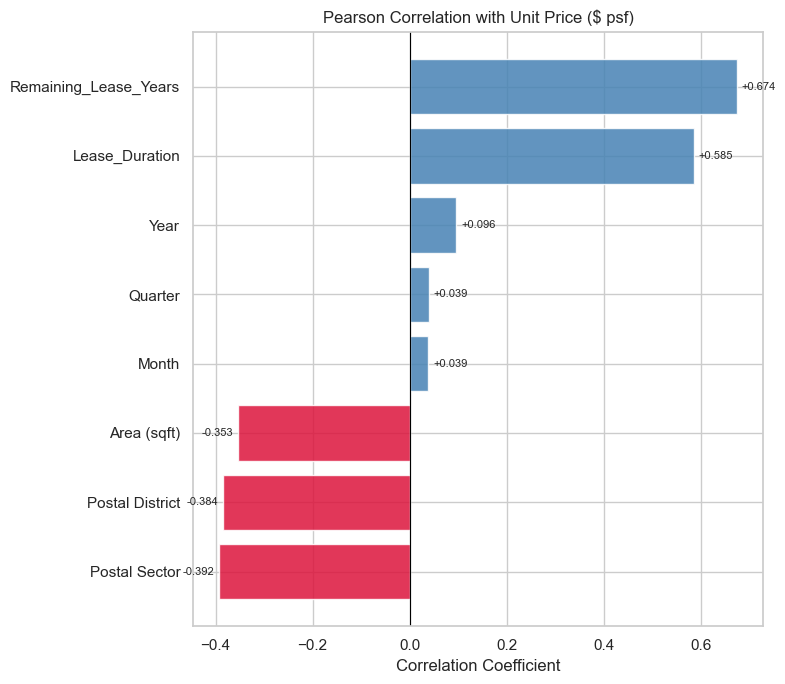


Correlation with target (sorted):
  +0.674  Remaining_Lease_Years *** HIGH ***
  +0.585  Lease_Duration *** HIGH ***
  +0.096  Year
  +0.039  Quarter
  +0.039  Month
  -0.353  Area (sqft) ** MOD **
  -0.384  Postal District ** MOD **
  -0.392  Postal Sector ** MOD **


In [10]:
property_cols = [c for c in num_cols if c not in macro_cols and c != "Unit Price ($ psf)"]
corr_target = df[property_cols + ["Unit Price ($ psf)"]].corr()["Unit Price ($ psf)"].drop("Unit Price ($ psf)").sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["crimson" if v < 0 else "steelblue" for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation with Unit Price ($ psf)")
ax.set_xlabel("Correlation Coefficient")

for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)

plt.tight_layout()
plt.show()

print("\nCorrelation with target (sorted):")
for feat, val in corr_target.sort_values(ascending=False).items():
    flag = " *** HIGH ***" if abs(val) > 0.5 else (" ** MOD **" if abs(val) > 0.3 else "")
    print(f"  {val:+.3f}  {feat}{flag}")

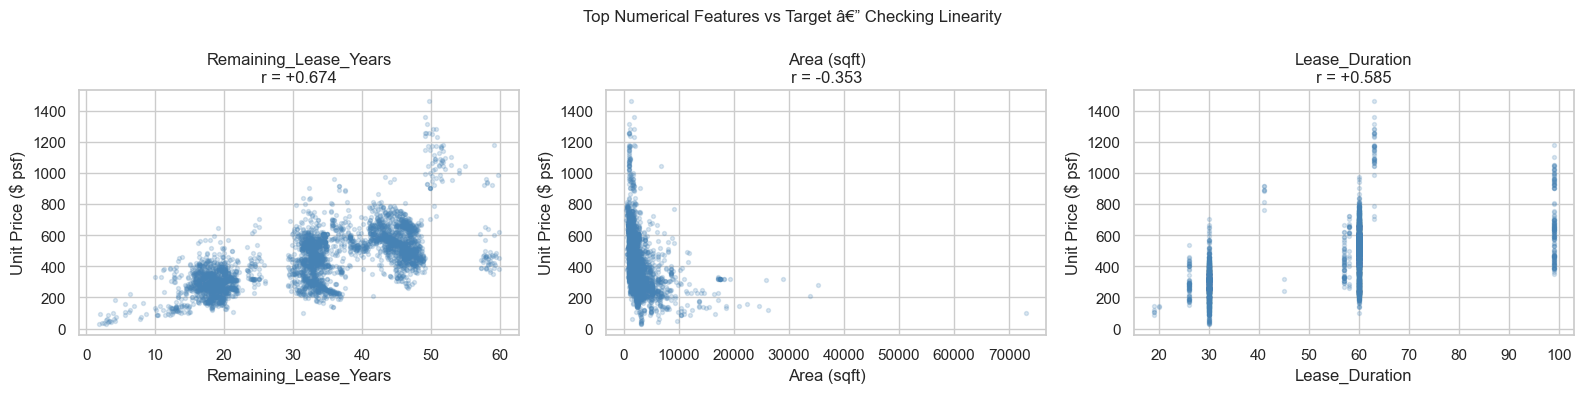

NOTE: Area (sqft) shows a curved relationship with target variable - bulk discount effect
      diminishes non-linearly as size increases. Log-transform recommended.
      Area skewness: 8.630


In [11]:
# Scatter plots - Top features vs target (to check linearity)
# Area (sqft) is included to show curved relationship â€” motivates log-transform in feature engineering

top_features = ["Remaining_Lease_Years", "Area (sqft)", "Lease_Duration"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(top_features):
    axes[i].scatter(df[col], df["Unit Price ($ psf)"], alpha=0.2, s=8, color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Unit Price ($ psf)")
    r = df[col].corr(df["Unit Price ($ psf)"])
    axes[i].set_title(f"{col}\nr = {r:+.3f}")

plt.suptitle("Top Numerical Features vs Target â€” Checking Linearity", fontsize=12)
plt.tight_layout()
plt.show()

print("NOTE: Area (sqft) shows a curved relationship with target variable - bulk discount effect")
print("      diminishes non-linearly as size increases. Log-transform recommended.")
print(f"      Area skewness: {df['Area (sqft)'].skew():.3f}")

## 9. Categorical Features vs Target

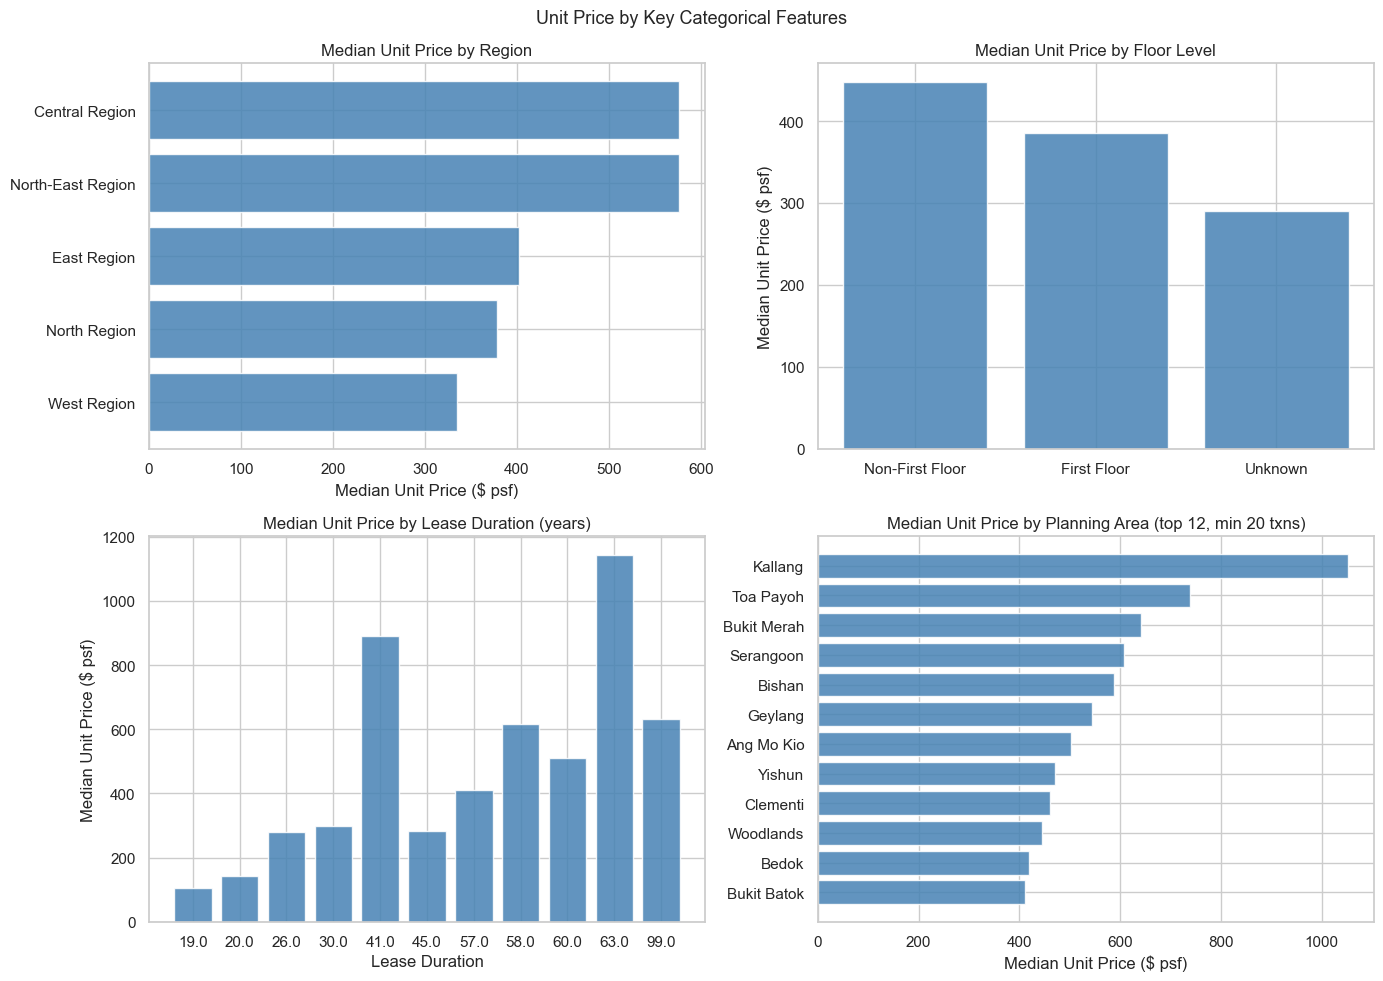


=== Unit Price by Region ===
                   median   mean  count
Region                                 
Central Region      576.0  589.0    940
North-East Region   576.0  549.8    195
East Region         402.0  412.6    429
North Region        379.0  390.7   1035
West Region         335.0  361.2   1190

=== Unit Price by Floor Level ===
                 median   mean  count
Floor Level                          
Non-First Floor   448.0  449.6   3284
First Floor       385.0  408.9    415
Unknown           290.0  285.7     90

=== Unit Price by Lease Duration ===
                median    mean  count
Lease_Duration                       
19.0             106.0   111.4      5
20.0             142.5   142.5      2
26.0             279.0   291.6     64
30.0             297.0   290.1   1105
41.0             890.0   867.3      7
45.0             282.5   282.5      2
57.0             409.5   418.3     54
58.0             615.5   550.3     24
60.0             509.0   491.5   2345
63.0     

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Region
region_stats = df.groupby("Region")["Unit Price ($ psf)"].agg(["median","mean","count"]).sort_values("median", ascending=False).round(1)
axes[0, 0].barh(region_stats.index, region_stats["median"], color="steelblue", alpha=0.85)
axes[0, 0].set_title("Median Unit Price by Region")
axes[0, 0].set_xlabel("Median Unit Price ($ psf)")
axes[0, 0].invert_yaxis()

# Floor Level
fl_stats = df.groupby("Floor Level")["Unit Price ($ psf)"].agg(["median","mean","count"]).sort_values("median", ascending=False).round(1)
axes[0, 1].bar(fl_stats.index, fl_stats["median"], color="steelblue", alpha=0.85)
axes[0, 1].set_title("Median Unit Price by Floor Level")
axes[0, 1].set_ylabel("Median Unit Price ($ psf)")

# Lease Duration
lease_stats = df.groupby("Lease_Duration")["Unit Price ($ psf)"].agg(["median","mean","count"]).sort_index().round(1)
axes[1, 0].bar(lease_stats.index.astype(str), lease_stats["median"], color="steelblue", alpha=0.85)
axes[1, 0].set_title("Median Unit Price by Lease Duration (years)")
axes[1, 0].set_xlabel("Lease Duration")
axes[1, 0].set_ylabel("Median Unit Price ($ psf)")

# Top planning areas (min 20 transactions)
pa_stats = df.groupby("Planning Area")["Unit Price ($ psf)"].agg(["median","mean","count"])
pa_stats = pa_stats[pa_stats["count"] >= 20].sort_values("median", ascending=False).head(12).round(1)
axes[1, 1].barh(pa_stats.index, pa_stats["median"], color="steelblue", alpha=0.85)
axes[1, 1].set_title("Median Unit Price by Planning Area (top 12, min 20 txns)")
axes[1, 1].set_xlabel("Median Unit Price ($ psf)")
axes[1, 1].invert_yaxis()

plt.suptitle("Unit Price by Key Categorical Features", fontsize=13)
plt.tight_layout()
plt.show()

print("\n=== Unit Price by Region ===")                             
print(region_stats.to_string())                                       
                                                                    
print("\n=== Unit Price by Floor Level ===")                        
print(fl_stats.to_string())                                           
                                                                    
print("\n=== Unit Price by Lease Duration ===")                     
print(lease_stats.to_string())                                        
                                                                    
print("\n=== Unit Price by Planning Area (min 20 txns, top 12) ===")
print(pa_stats.to_string()) 

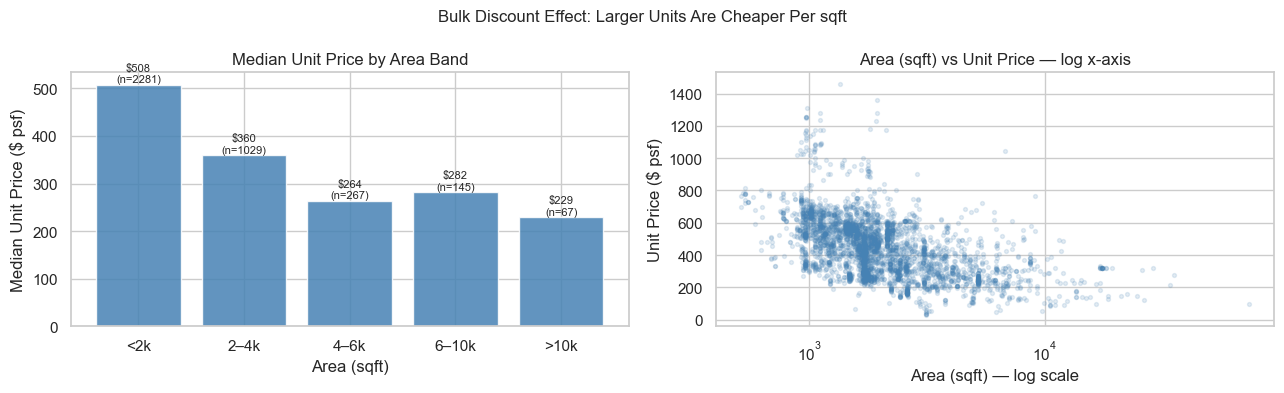

=== Unit Price by Area Band ===
             median   mean  count
Area (sqft)                      
<2k           508.0  504.5   2281
2–4k          360.0  374.6   1029
4–6k          264.0  289.0    267
6–10k         282.0  295.9    145
>10k          229.0  235.1     67


In [13]:
# Area band bulk discount
area_bands = pd.cut(
    df["Area (sqft)"],
    bins=[0, 2000, 4000, 6000, 10000, 99999],
    labels=["<2k", "2–4k", "4–6k", "6–10k", ">10k"]
)
area_stats = df.groupby(area_bands, observed=True)["Unit Price ($ psf)"].agg(["median","mean","count"]).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart — median psf by area band
axes[0].bar(area_stats.index, area_stats["median"],
color="steelblue", alpha=0.85)
axes[0].set_title("Median Unit Price by Area Band")
axes[0].set_xlabel("Area (sqft)")
axes[0].set_ylabel("Median Unit Price ($ psf)")
for i, (v, n) in enumerate(zip(area_stats["median"],
area_stats["count"])):
    axes[0].text(i, v + 5, f"${v:.0f}\n(n={n:.0f})", ha="center",
fontsize=8)

# Scatter — Area vs Unit Price (log scale to show curve)
axes[1].scatter(df["Area (sqft)"], df["Unit Price ($ psf)"],
alpha=0.15, s=8, color="steelblue")
axes[1].set_xscale("log")
axes[1].set_title("Area (sqft) vs Unit Price — log x-axis")
axes[1].set_xlabel("Area (sqft) — log scale")
axes[1].set_ylabel("Unit Price ($ psf)")

plt.suptitle("Bulk Discount Effect: Larger Units Are Cheaper Per sqft", fontsize=12)
plt.tight_layout()
plt.show()

print("=== Unit Price by Area Band ===")
print(area_stats.to_string())

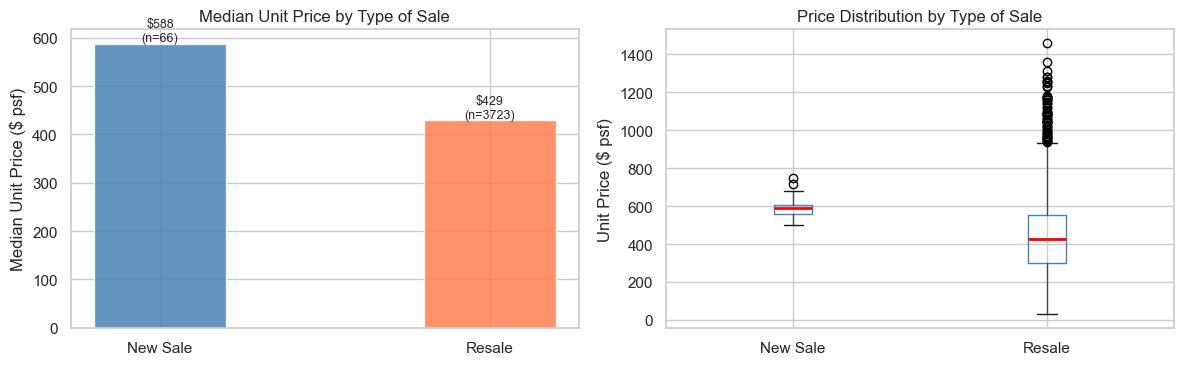

=== Unit Price by Type of Sale ===
              median   mean  count
Type of Sale                      
New Sale       588.0  576.1     66
Resale         429.0  438.9   3723


In [14]:
# Type of Sale — price distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sale_stats = df.groupby("Type of Sale")["Unit Price ($ psf)"].agg(["median","mean","count"]).round(1)

# Bar chart — median psf by sale type
axes[0].bar(sale_stats.index, sale_stats["median"],
color=["steelblue","coral"], alpha=0.85, width=0.4)
axes[0].set_title("Median Unit Price by Type of Sale")
axes[0].set_ylabel("Median Unit Price ($ psf)")
for i, (v, n) in enumerate(zip(sale_stats["median"],sale_stats["count"])):
    axes[0].text(i, v + 5, f"${v:.0f}\n(n={n:.0f})", ha="center", fontsize=9)

# Box plot — full distribution comparison
df.boxplot(column="Unit Price ($ psf)", by="Type of Sale", ax=axes[1],
        boxprops=dict(color="steelblue"),
medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Price Distribution by Type of Sale")
axes[1].set_xlabel("")
axes[1].set_ylabel("Unit Price ($ psf)")
plt.suptitle("")

plt.tight_layout()
plt.show()

print("=== Unit Price by Type of Sale ===")
print(sale_stats.to_string())

### Eta-Squared (η²) — Association Between Categorical Features and Target

Eta-squared measures how much of the **variance in the target** (`Unit Price ($ psf)`) is explained by a categorical grouping. It is the categorical equivalent of R².

$$\eta^2 = 
rac{SS_{between}}{SS_{total}}$$

| η² value | Interpretation |
|----------|---------------|
| < 0.01 | Negligible |
| 0.01 – 0.06 | Small |
| 0.06 – 0.14 | Medium |
| > 0.14 | Large |

Unlike Pearson r, eta-squared captures **non-linear group differences** — it measures whether knowing a unit's category lets you predict its price better than the overall mean, regardless of ordering.

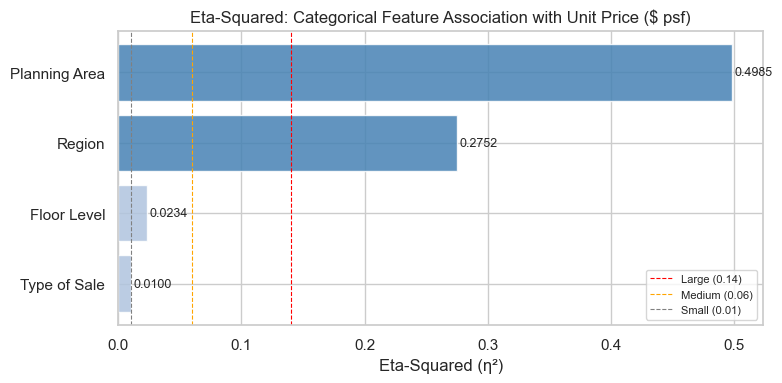

=== Eta-Squared Results ===
      Feature  Eta-Squared  N Groups
Planning Area       0.4985        24
       Region       0.2752         5
  Floor Level       0.0234         3
 Type of Sale       0.0100         2


In [15]:
import numpy as np

def eta_squared(df, cat_col, target_col):
    """Compute eta-squared for a categorical feature vs a continuous target."""
    groups = df.groupby(cat_col)[target_col].apply(list)
    grand_mean = df[target_col].mean()
    ss_total = ((df[target_col] - grand_mean) ** 2).sum()
    ss_within = sum(
        ((np.array(g) - np.mean(g)) ** 2).sum()
        for g in groups
    )
    ss_between = ss_total - ss_within
    return ss_between / ss_total

cat_cols = ["Planning Area", "Region", "Floor Level", "Type of Sale"]
target_col = "Unit Price ($ psf)"

results = []
for col in cat_cols:
    eta2 = eta_squared(df, col, target_col)
    n_groups = df[col].nunique()
    results.append({"Feature": col, "Eta-Squared": round(eta2, 4), "N Groups": n_groups})

eta_df = (
    __import__('pandas').DataFrame(results)
    .sort_values("Eta-Squared", ascending=False)
    .reset_index(drop=True)
)

# Chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["steelblue" if v > 0.14 else ("cornflowerblue" if v > 0.06 else "lightsteelblue")
          for v in eta_df["Eta-Squared"]]
bars = ax.barh(eta_df["Feature"], eta_df["Eta-Squared"], color=colors, alpha=0.85)
ax.axvline(0.14, color="red", linestyle="--", linewidth=0.8, label="Large (0.14)")
ax.axvline(0.06, color="orange", linestyle="--", linewidth=0.8, label="Medium (0.06)")
ax.axvline(0.01, color="grey", linestyle="--", linewidth=0.8, label="Small (0.01)")
for bar, val in zip(bars, eta_df["Eta-Squared"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)
ax.set_title("Eta-Squared: Categorical Feature Association with Unit Price ($ psf)")
ax.set_xlabel("Eta-Squared (η²)")
ax.legend(fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("=== Eta-Squared Results ===")
print(eta_df.to_string(index=False))

## 10. Data Quality Flags

In [16]:
# IQR-based outliers on target
q1 = target.quantile(0.25)
q3 = target.quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

lower_outliers = df[target < lower]
upper_outliers = df[target > upper]

issues = {
    "Duplicate rows": df.duplicated().sum(),
    f"Target outliers — lower (price < ${lower:.0f}, IQR artefact)": len(lower_outliers),
    f"Target outliers — upper (price > ${upper:.0f})": len(upper_outliers),
    "Missing Project Name": df["Project Name"].isna().sum(),
    "Floor Level = Unknown": (df["Floor Level"] == "Unknown").sum(),
    "Type of Sale = New Sale (rare class)": (df["Type of Sale"] == "New Sale").sum(),
    "Remaining Lease < 5 years": (df["Remaining_Lease_Years"] < 5).sum(),
    "Area > 10,000 sqft (large units)": (df["Area (sqft)"] > 10000).sum(),
}

print(f"{'Issue':<60} {'Count':>6}  {'% of Total':>10}")
print("-" * 80)
for desc, count in issues.items():
    pct = count / len(df) * 100
    print(f"{desc:<60} {count:>6}  {pct:>9.2f}%")

print()
print("Notes:")
print(f"  Lower fence ${lower:.0f} is an IQR artefact — prices cannot be negative, 0 lower outliers.")
print(f"  Upper outliers (n={len(upper_outliers)}) are legitimate premium properties:")
top = (df[target > upper]
       .groupby(["Planning Area", "Lease_Duration"])
       .agg(count=("Unit Price ($ psf)", "count"),
            median_psf=("Unit Price ($ psf)", "median"))
       .sort_values("count", ascending=False)
       .head(5))
print(top.to_string())
print()
print("  Recommendation: RETAIN — these are genuine high-value transactions,")
print("  not data errors. Removing them would bias the model to underpredict")
print("  premium Kallang / long-lease units.")

Issue                                                         Count  % of Total
--------------------------------------------------------------------------------
Duplicate rows                                                    0       0.00%
Target outliers — lower (price < $-82, IQR artefact)              0       0.00%
Target outliers — upper (price > $942)                           61       1.61%
Missing Project Name                                             26       0.69%
Floor Level = Unknown                                            90       2.38%
Type of Sale = New Sale (rare class)                             66       1.74%
Remaining Lease < 5 years                                        17       0.45%
Area > 10,000 sqft (large units)                                 67       1.77%

Notes:
  Lower fence $-82 is an IQR artefact — prices cannot be negative, 0 lower outliers.
  Upper outliers (n=61) are legitimate premium properties:
                              count  median_psf

## 11. Macro Features Assessment

Macro features - unique value counts (all transactions share quarterly values):
  GDP_YoY_Growth_Rate           :  12 unique values
  CPI_All_Items                 :  12 unique values
  Unemployment_Rate             :   5 unique values
  Price_Index                   :  12 unique values
  5Y_Bond_Yield                 :  33 unique values
  2Y_Bond_Yield                 :  34 unique values
  10Y_Bond_Yield                :  33 unique values
  1Y_TBills                     :  32 unique values
  15Y_Bond_Yield                :  31 unique values
  20Y_Bond_Yield                :  29 unique values
  SORA_3M_Compounded            :  36 unique values
  Cement_Bulk_Per_Tonne         :  34 unique values
  Steel_Rebar_Per_Tonne         :  36 unique values
  Granite_20mm_Per_Tonne        :  18 unique values
  Concreting_Sand_Per_Tonne     :  22 unique values
  Ready_Mixed_Concrete_Per_m3   :  22 unique values


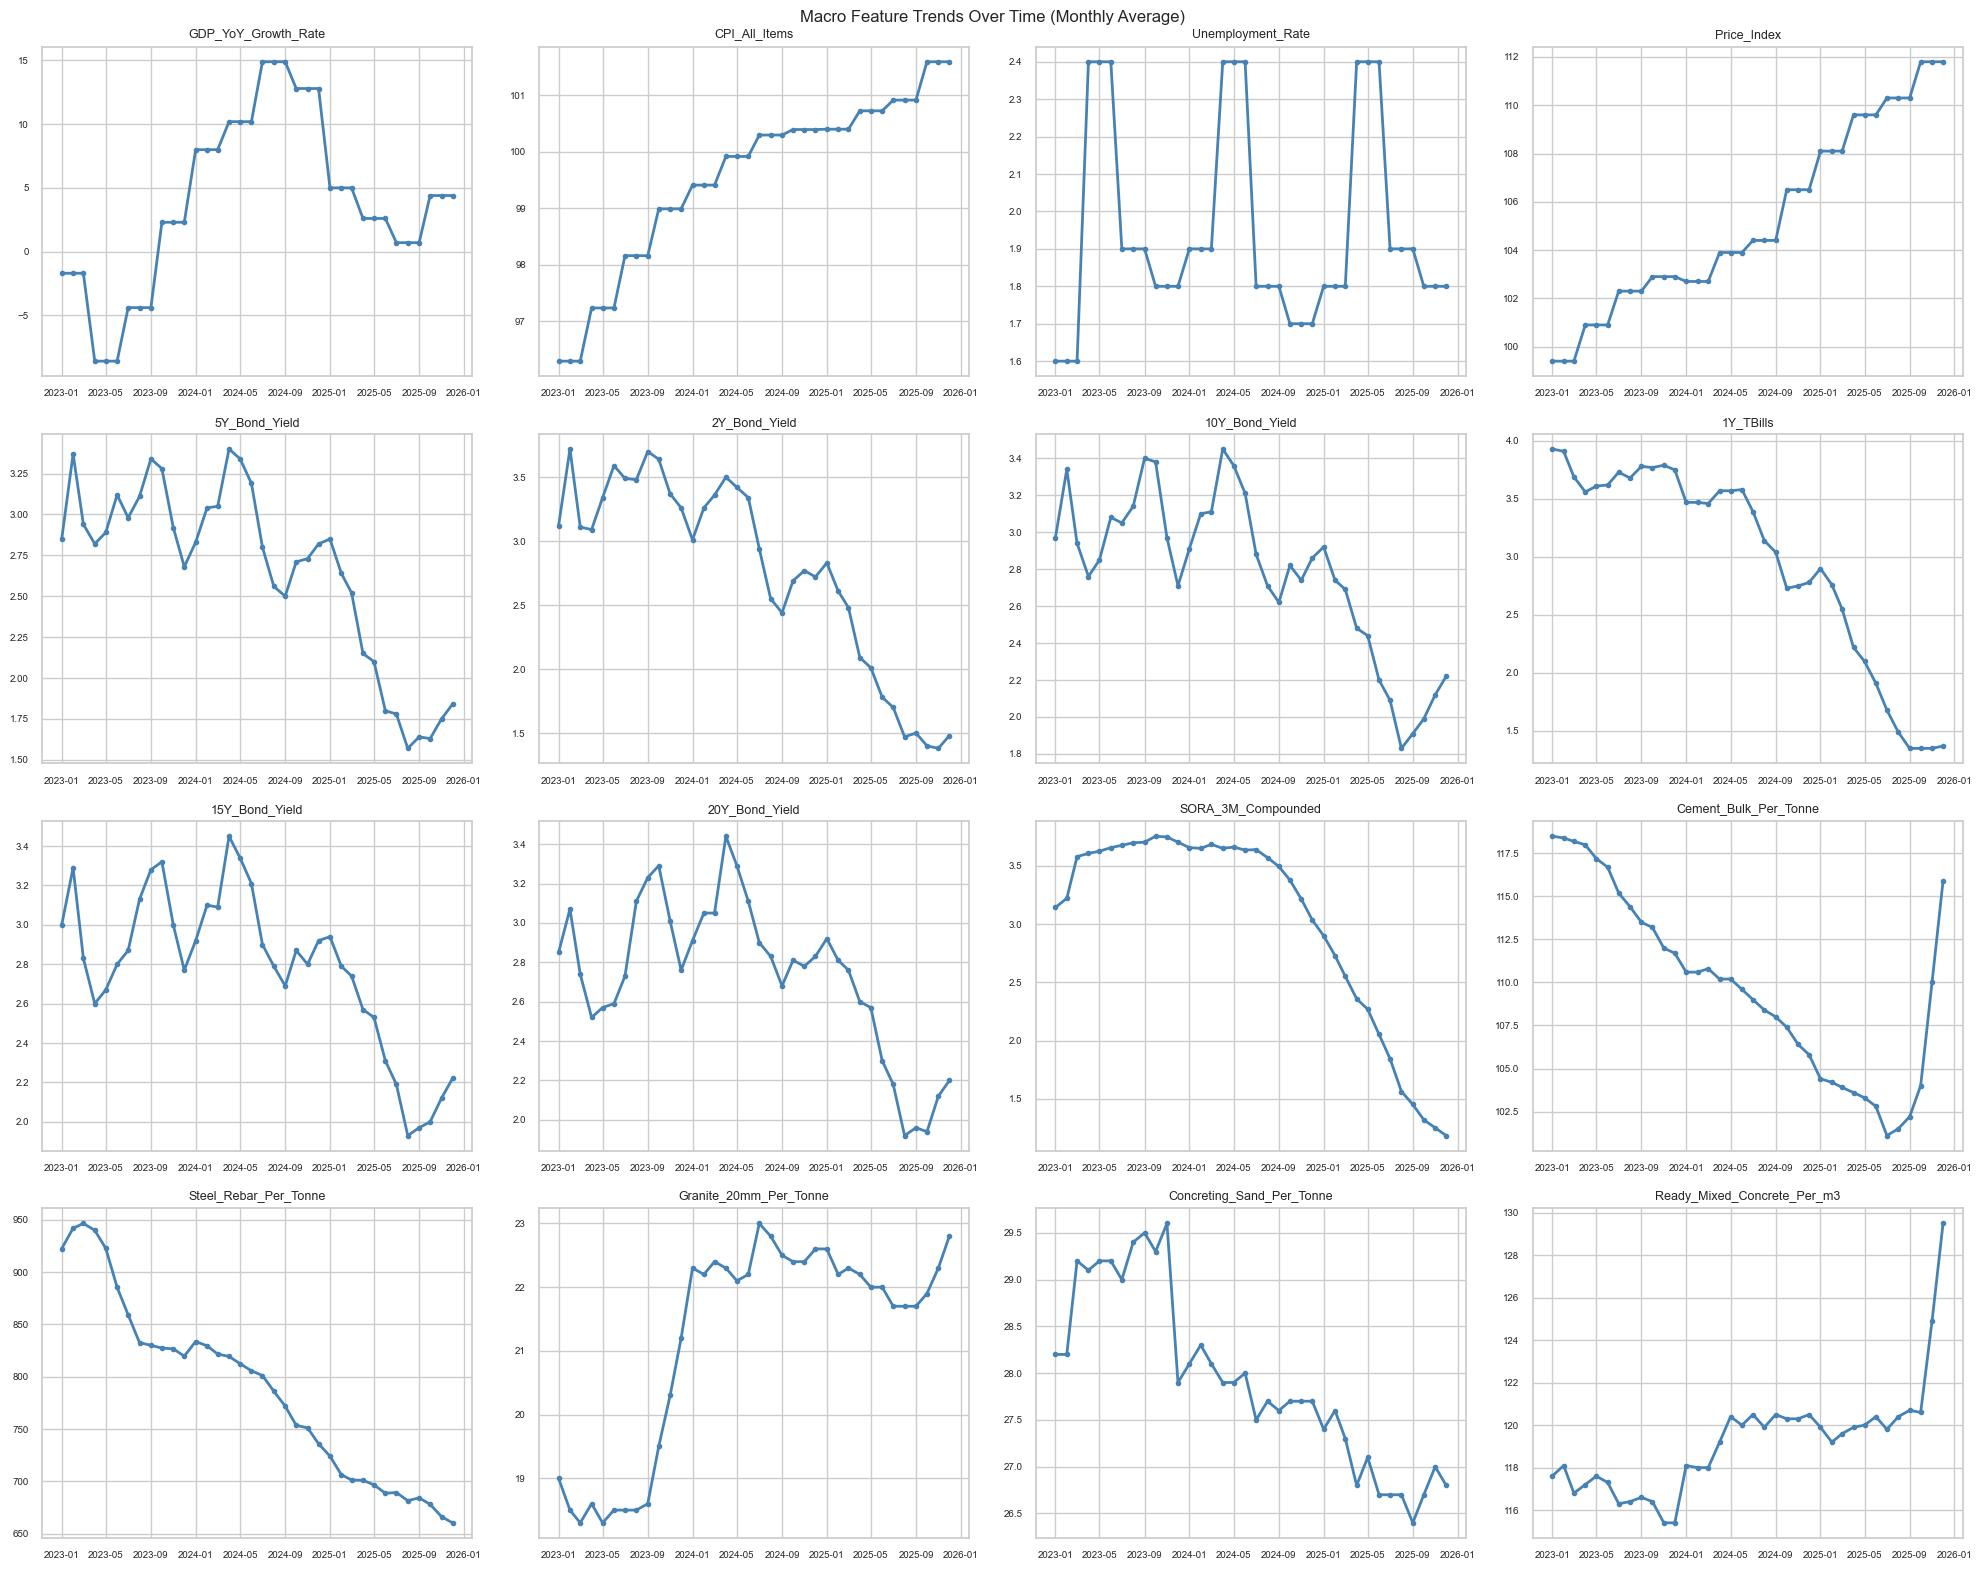

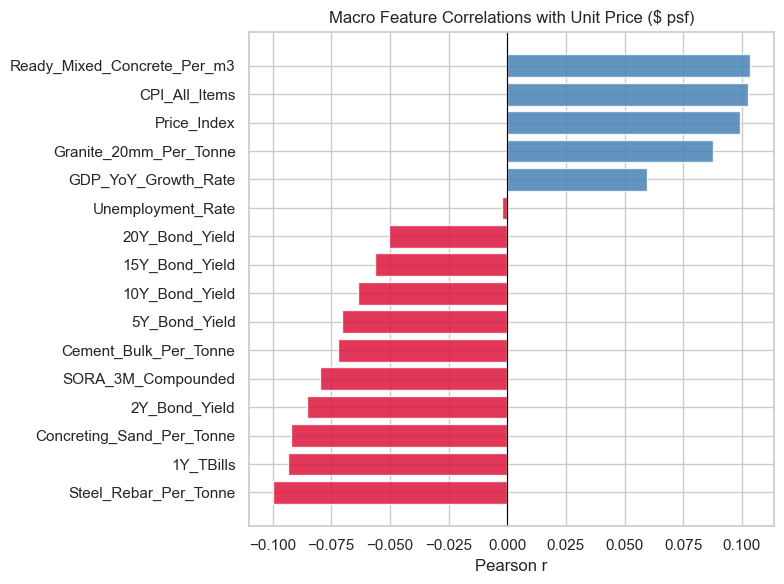

Macro feature correlations with target:
  +0.104  Ready_Mixed_Concrete_Per_m3
  +0.103  CPI_All_Items
  +0.099  Price_Index
  +0.088  Granite_20mm_Per_Tonne
  +0.060  GDP_YoY_Growth_Rate
  -0.002  Unemployment_Rate
  -0.050  20Y_Bond_Yield
  -0.056  15Y_Bond_Yield
  -0.063  10Y_Bond_Yield
  -0.070  5Y_Bond_Yield
  -0.072  Cement_Bulk_Per_Tonne
  -0.080  SORA_3M_Compounded
  -0.085  2Y_Bond_Yield
  -0.092  Concreting_Sand_Per_Tonne
  -0.093  1Y_TBills
  -0.100  Steel_Rebar_Per_Tonne


In [17]:
macro_cols = [
    "GDP_YoY_Growth_Rate", "CPI_All_Items", "Unemployment_Rate", "Price_Index",
    "5Y_Bond_Yield", "2Y_Bond_Yield", "10Y_Bond_Yield", "1Y_TBills",
    "15Y_Bond_Yield", "20Y_Bond_Yield", "SORA_3M_Compounded",
    "Cement_Bulk_Per_Tonne", "Steel_Rebar_Per_Tonne",
    "Granite_20mm_Per_Tonne", "Concreting_Sand_Per_Tonne", "Ready_Mixed_Concrete_Per_m3",
]

print("Macro features - unique value counts (all transactions share quarterly values):")
for col in macro_cols:
    print(f"  {col:<30}: {df[col].nunique():>3} unique values")

# Macro feature trends over time
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

monthly_macro = df.groupby(df["Contract Date"].dt.to_period("M"))[macro_cols].mean().reset_index()
monthly_macro["Contract Date"] = monthly_macro["Contract Date"].dt.to_timestamp()

for i, col in enumerate(macro_cols):
    axes[i].plot(monthly_macro["Contract Date"], monthly_macro[col],
                 color="steelblue", linewidth=2, marker="o", markersize=3)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

plt.suptitle("Macro Feature Trends Over Time (Monthly Average)", fontsize=12)
plt.tight_layout()
plt.show()

# Macro features — correlation with target
macro_corr = df[macro_cols + ["Unit Price ($ psf)"]].corr()["Unit Price ($ psf)"].drop("Unit Price ($ psf)").sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["crimson" if v < 0 else "steelblue" for v in macro_corr.values]
ax.barh(macro_corr.index, macro_corr.values, color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Macro Feature Correlations with Unit Price ($ psf)")
ax.set_xlabel("Pearson r")
plt.tight_layout()
plt.show()

print("Macro feature correlations with target:")
for feat, r in macro_corr.sort_values(ascending=False).items():
    print(f"  {r:+.3f}  {feat}")

## 12. EDA Summary & Recommendations

### Key Findings

| # | Finding | Action |
|---|---------|--------|
| 1 | `Remaining_Lease_Years` (r=+0.674) and `Lease_Duration` (r=+0.585) are the strongest predictors | Prioritise in feature selection; check collinearity between them |
| 2 | `Postal_Sector` (r=-0.392) and `Postal_District` (r=-0.384) appear as moderate predictors | **Drop both** — they are numerical codes (identifiers), not true continuous variables. The correlation is a coincidence of Singapore's postal numbering. Location is better captured by `Region` and `Planning Area` |
| 3 | `Area (sqft)` (r=-0.353) is a moderate predictor | Keep — reflects genuine bulk discount effect. Consider log-transform |
| 4 | `Unemployment_Rate` (r=-0.002) has near-zero correlation with target | Drop — near-constant (only 5 unique values), no meaningful signal |
| 5 | Target is right-skewed (skew=0.83) | Consider log-transform for linear models |
| 6 | No duplicate rows after cleaning pipeline | Confirmed clean — composite key dedup in notebook 01a |
| 7 | `Type Of Area = Land` rows removed | Already excluded in cleaning pipeline (notebook 01a) |
| 8 | `Type of Sale = New Sale` (66 rows, 1.7%) | Consider merging with Resale or dropping |
| 9 | `Floor Level = Unknown` (90 rows) | Treat as a separate category |
| 10 | 8 macro features are quarterly aggregates (5–36 unique values) | High multicollinearity risk — investigate in next notebook |
| 11 | `Year`, `Month`, `Quarter` are mapping keys used to join macro data | Exclude from model features entirely |

## 12a. Business Insights

These findings translate directly to how buyers, tenants, and valuers price Singapore factory units.

### 1. Lease Remaining Years is the Dominant Pricing Driver
Factory prices rise steeply and non-linearly with remaining lease.
The market applies a heavy discount to short-lease assets.

| Remaining Lease | Median psf | vs Baseline (<20 yrs) |
|----------------|-----------|----------------------|
| < 20 years | $280 | — |
| 20–30 years | $316 | +13% |
| 30–40 years | $457 | +63% |
| 40–50 years | $556 | +99% |
| 50–60 years | $922 | +229% |

**Implication**: A factory with 55 years remaining is priced 3.3×
higher per sqft than one with 15 years. Lease remaining is not a
linear discount — the market front-loads value for long-lease
assets. Short-lease units near expiry face a valuation cliff.

---

### 2. Location Premium: Central/NE vs West
The West is the industrial heartland (31% of transactions) but
commands the lowest prices.

| Region | Median psf | Premium over West |
|--------|-----------|-------------------|
| Central | $576 | +72% |
| North-East | $576 | +72% |
| East | $402 | +20% |
| North | $379 | +13% |
| West | $335 | — |

At planning area level, **Kallang** is the standout at $1,051
median psf — 3.1× Jurong West ($314). Proximity to the CBD and Paya
Lebar commercial hub justifies the premium.

**Implication**: Location is the second most important lever after
lease. Businesses that can operate in the West achieve the lowest
occupancy cost.

---

### 3. Unit Size and Bulk Discount
Smaller units are significantly more expensive per
sqft — steep and non-linear.

| Unit Size | Median psf | vs Large (>10k sqft) |
|-----------|-----------|----------------------|
| < 2,000 sqft | $508 | +122% |
| 2,000–4,000 sqft | $360 | +57% |
| 4,000–6,000 sqft | $264 | +15% |
| > 10,000 sqft | $229 | — |

**Implication**: SMEs needing small units pay a
substantial per-sqft premium. Large-footprint
occupiers benefit from bulk discounts but face a thin
market (only 66 transactions above 10k sqft over 3
years).



---

### 4. Floor Level Premium
Non-first-floor units command a 16% median premium ($448 vs $385).
First-floor units are associated with loading bay and heavy-access
use, which reduces per-sqft value for general industrial purposes.

---

### 5. New Sale Premium and Supply Scarcity
New Sale units fetch a 37% premium ($588 vs $429
resale) with only 66 new transactions over 3 years —
new industrial supply is extremely tight. The
secondary market dominates at 98.3% of transactions.

---

### 6. Macro Factors Have Weak Direct Influence
All macro features show |r| < 0.11 with unit price.
Property-level characteristics (lease, size, location)
dominate pricing. Macro conditions affect broad
market sentiment but do not directly drive individual
transaction prices.


### Next Step
→ `notebooks/03_multicollinearity_analysis.ipynb` — VIF analysis and feature selection